## 1. Importera bibliotek
Vi börjar med att importera alla nödvändiga bibliotek för datahantering, visualisering och maskininlärning.

In [61]:
import pandas as pd # For data handling (loading and manipulating the dataset)
import numpy as np
import matplotlib.pyplot as plt   # For plotting graphs and charts
from sklearn.model_selection import train_test_split   # For splitting data into train and test sets
from sklearn.linear_model import LogisticRegression   # Logistic Regression model
from sklearn.metrics import accuracy_score, classification_report   # To evaluate model performance
from imblearn.over_sampling import RandomOverSampler   # To balance dataset classes (oversampling)import numpy as np
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay

## 2. Läs in datasetet
Vi laddar in CSV-filen och tittar på de första raderna för att säkerställa att allt ser korrekt ut.

In [62]:
# Load the Spotify dataset
df = pd.read_csv('Popular_Spotify_Songs (1).csv', encoding='latin1')   # Read CSV with latin1 encoding (handles special chars)
df.head()   # Show first 5 rows to confirm the dataset loaded correctly

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


## 3. Skapa ny target-kolumn
Vi klassificerar låtar som **populär** (≥ 5000 spellistor) eller **inte populär** (< 5000 spellistor).

In [63]:
# Define a function to classify songs as 'popular' or 'not popular'
def classify_popularity(playlist_count):   # playlist_count = number of Spotify playlists the song is in
    if playlist_count >= 5000:   # If >= 5000 playlists → considered popular
        return 'populär'
    else:
        return 'inte populär'

# Apply the function to create a new column 'popularity_category'
df['popularity_category'] = df['in_spotify_playlists'].apply(classify_popularity)

## 4. Förbered data (encoding av kategoriska variabler)
Vi gör om `mode` och `key` till numeriska variabler så att modellen kan förstå dem.

In [64]:
    # Encode categorical columns into numeric format
    df['mode_encoded'] = df['mode'].map({'Major':1, 'Minor':0})   # Convert 'Major'=1, 'Minor'=0
    df = pd.get_dummies(df, columns=['key'], prefix='key')   # One-hot encode 'key' column

    # Select relevant numeric features for prediction
    feature_columns = ['bpm', 'danceability_%', 'valence_%', 'energy_%',
                       'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']

    # Define X (features) and y (target)
    X = df[feature_columns]   # Features = numeric columns selected above
    y = df['popularity_category']   # Target = popular or not popular

## 5. Visualisera klassfördelning före balansering
Här ser vi att datasetet är obalanserat (fler låtar i en kategori än den andra).

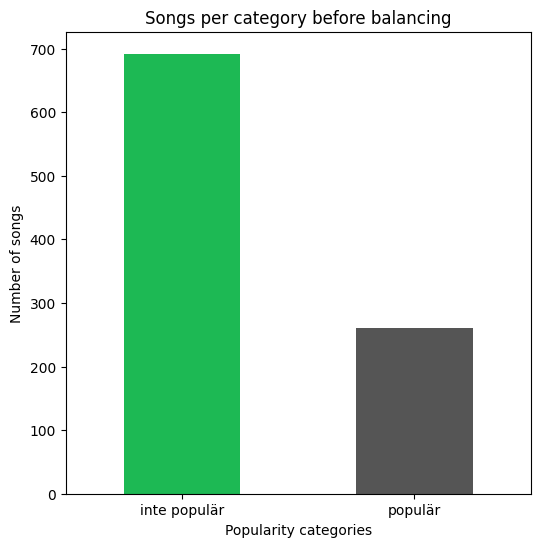

In [65]:
# Visualize class imbalance before balancing
original_counts = y.value_counts()   # Count how many songs are in each category
plt.figure(figsize=(6,6))
original_counts.plot(kind='bar', color=['#1DB954', '#555555'])   # Plot bar chart
plt.title('Songs per category before balancing')
plt.xlabel('Popularity categories')
plt.ylabel('Number of songs')
plt.xticks(rotation=0)
plt.show()

## 6. Baseline-modell (utan balansering)
Vi tränar en första Logistic Regression på obalanserade data och utvärderar den.

In [66]:
# Split dataset into train and test for baseline model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   # 80% train, 20% test

# Train Logistic Regression baseline model
baseline_model = LogisticRegression(max_iter=1000, random_state=42)   # Initialize model
baseline_model.fit(X_train, y_train)   # Train model

# Predict on test set
y_pred_base = baseline_model.predict(X_test)

# Evaluate model
print('Baseline accuracy:', accuracy_score(y_test, y_pred_base))   # Print accuracy
print(classification_report(y_test, y_pred_base, zero_division=0))   # Detailed classification report

Baseline accuracy: 0.7382198952879581
              precision    recall  f1-score   support

inte populär       0.74      1.00      0.85       141
     populär       0.00      0.00      0.00        50

    accuracy                           0.74       191
   macro avg       0.37      0.50      0.42       191
weighted avg       0.54      0.74      0.63       191



## 7. Balansera datasetet
Vi använder **RandomOverSampler** för att skapa lika många exempel i båda klasserna.

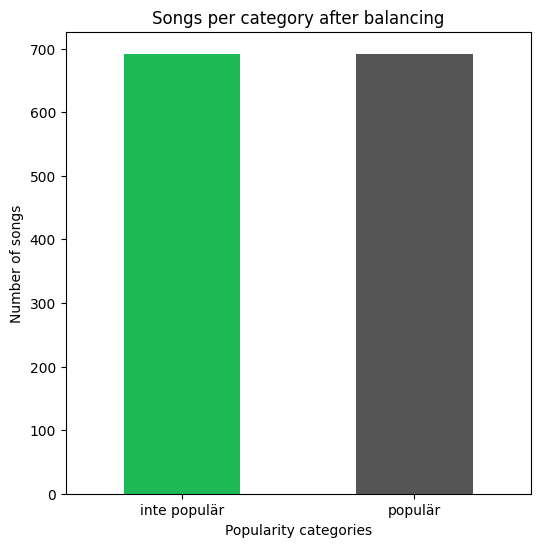

Counts after balancing: popularity_category
inte populär    692
populär         692
Name: count, dtype: int64


In [67]:
# Balance dataset using oversampling
oversampler = RandomOverSampler(random_state=42)   # Initialize oversampler
X_resampled, y_resampled = oversampler.fit_resample(X, y)   # Apply oversampling to balance classes

# Show class counts after balancing
balanced_counts = y_resampled.value_counts()
plt.figure(figsize=(6,6))
balanced_counts.plot(kind='bar', color=['#1DB954', '#555555'])
plt.title('Songs per category after balancing')
plt.xlabel('Popularity categories')
plt.ylabel('Number of songs')
plt.xticks(rotation=0)
plt.show()

print('Counts after balancing:', y_resampled.value_counts())

## 8. Modell efter balansering
Vi tränar samma modell igen men nu på det balanserade datasetet och jämför resultatet.

In [68]:
# Train model again with balanced dataset
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000, random_state=42)   # Re-train Logistic Regression
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluate improved model
print('Optimized accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Optimized accuracy: 0.5234657039711191
              precision    recall  f1-score   support

inte populär       0.52      0.49      0.50       138
     populär       0.52      0.56      0.54       139

    accuracy                           0.52       277
   macro avg       0.52      0.52      0.52       277
weighted avg       0.52      0.52      0.52       277



In [69]:
# Correlation of numeric features vs in_spotify_playlists (and streams if present)

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
targets = [c for c in ["in_spotify_playlists", "streams"] if c in df.columns]

for tgt in targets:
    corr_matrix = df[num_cols].corr(numeric_only=True)  # only numeric cols

    if tgt not in corr_matrix.columns:
        print(f"⚠️ Target {tgt} not found in correlation matrix, skipping...")
        continue

    # Force Series, drop self-correlation
    corr_series = corr_matrix.loc[:, tgt].drop(labels=[tgt], errors="ignore")

    corr_sorted = corr_series.sort_values(ascending=False)

    print(f"\nTop correlations with {tgt}:")
    print(corr_sorted.head(12))

    print("\nBottom correlations:")
    print(corr_sorted.tail(10))


Top correlations with in_spotify_playlists:
in_apple_playlists    0.708277
in_apple_charts       0.271317
in_spotify_charts     0.164331
in_deezer_charts      0.144342
mode_encoded          0.048868
energy_%              0.033808
bpm                  -0.019598
valence_%            -0.021883
instrumentalness_%   -0.028134
liveness_%           -0.046695
acousticness_%       -0.064421
released_day         -0.079669
Name: in_spotify_playlists, dtype: float64

Bottom correlations:
valence_%            -0.021883
instrumentalness_%   -0.028134
liveness_%           -0.046695
acousticness_%       -0.064421
released_day         -0.079669
speechiness_%        -0.089722
artist_count         -0.101966
released_month       -0.104757
danceability_%       -0.106534
released_year        -0.392204
Name: in_spotify_playlists, dtype: float64
⚠️ Target streams not found in correlation matrix, skipping...


##Block C — Utility: label by threshold and single run eval

In [70]:
def label_by_threshold(threshold):
    """Return y labels using playlists >= threshold as 'populär'."""
    return np.where(df["in_spotify_playlists"] >= threshold, "populär", "inte populär")

def run_once(X, y, oversample=False, seed=42):
    """Train/test split, optional oversample, LogisticRegression, return metrics and preds."""
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    if oversample:
        ros = RandomOverSampler(random_state=seed)
        Xtr, ytr = ros.fit_resample(Xtr, ytr)
    clf = LogisticRegression(max_iter=1000, random_state=seed)
    clf.fit(Xtr, ytr)
    yhat = clf.predict(Xte)
    acc = accuracy_score(yte, yhat)
    f1  = f1_score(yte, yhat, average="macro")
    return acc, f1, (yte, yhat), clf, (Xtr, Xte, ytr, yte)

Block D — Show train-set class balance at your current threshold (5000)


Train class counts (5000):
inte populär    553
populär         209
Name: count, dtype: int64

Train class share (5000):
inte populär    0.726
populär         0.274
Name: proportion, dtype: float64


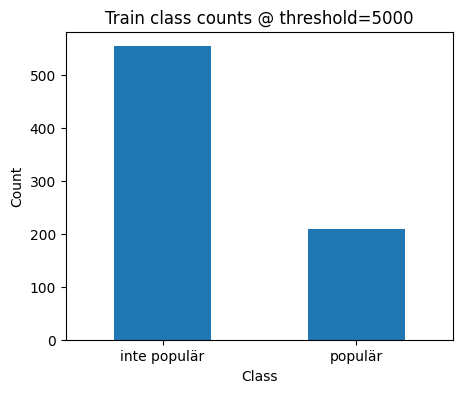

In [71]:
# Rebuild y at 5000 to be explicit
y_5000 = label_by_threshold(5000)

# Split once to report TRAIN distribution (teacher asked for train set)
Xtr, Xte, ytr, yte = train_test_split(
    X, y_5000, test_size=0.2, random_state=42, stratify=y_5000
)

# Convert ytr to Series so we can use value_counts()
ytr = pd.Series(ytr)

print("Train class counts (5000):")
print(ytr.value_counts())
print("\nTrain class share (5000):")
print(ytr.value_counts(normalize=True).round(3))

# Plot train distribution
plt.figure(figsize=(5,4))
ytr.value_counts().plot(kind="bar")
plt.title("Train class counts @ threshold=5000")
plt.xlabel("Class"); plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

Block E — Threshold sweep (class balance + metrics)


In [72]:
thresholds = [2000, 3000, 5000, 7000, 10000]
rows = []

for thr in thresholds:
    y_thr = label_by_threshold(thr)
    # record whole-dataset class share
    whole_share = pd.Series(y_thr).value_counts(normalize=True).to_dict()
    # eval baseline and oversampled
    acc_b, f1_b, _, _, _ = run_once(X, y_thr, oversample=False)
    acc_o, f1_o, _, _, _ = run_once(X, y_thr, oversample=True)
    rows.append({
        "threshold": thr,
        "share_popular": whole_share.get("populär", 0.0),
        "share_not": whole_share.get("inte populär", 0.0),
        "acc_baseline": acc_b, "f1_baseline": f1_b,
        "acc_oversampled": acc_o, "f1_oversampled": f1_o
    })

sweep = pd.DataFrame(rows)
sweep

,threshold,share_popular,share_not,acc_baseline,f1_baseline,acc_oversampled,f1_oversampled
0,2000,0.526758,0.473242,0.513089,0.497155,0.518325,0.513511
1,3000,0.399790,0.600210,0.570681,0.464657,0.502618,0.501251
2,5000,0.273872,0.726128,0.727749,0.421212,0.565445,0.538688
3,7000,0.205666,0.794334,0.795812,0.443149,0.528796,0.486191
4,10000,0.141658,0.858342,0.858639,0.461972,0.570681,0.492416


Plots

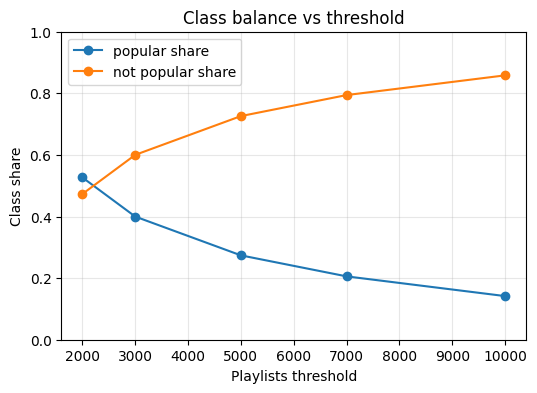

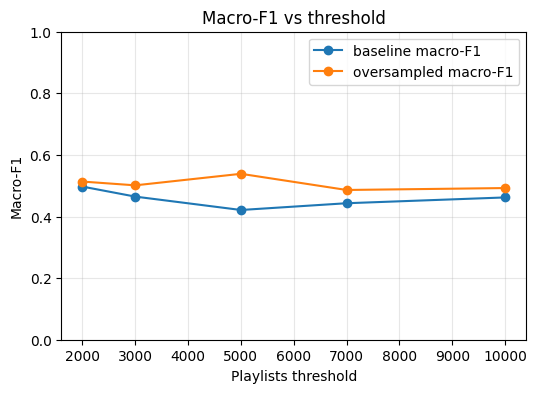

In [73]:
# Class share vs threshold
plt.figure(figsize=(6,4))
plt.plot(sweep["threshold"], sweep["share_popular"], marker="o", label="popular share")
plt.plot(sweep["threshold"], sweep["share_not"], marker="o", label="not popular share")
plt.ylim(0,1); plt.xlabel("Playlists threshold"); plt.ylabel("Class share")
plt.title("Class balance vs threshold"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

# Macro-F1 vs threshold (baseline vs oversampled)
plt.figure(figsize=(6,4))
plt.plot(sweep["threshold"], sweep["f1_baseline"], marker="o", label="baseline macro-F1")
plt.plot(sweep["threshold"], sweep["f1_oversampled"], marker="o", label="oversampled macro-F1")
plt.ylim(0,1); plt.xlabel("Playlists threshold"); plt.ylabel("Macro-F1")
plt.title("Macro-F1 vs threshold"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

Block F — Pick best threshold by macro-F1 (oversampled)

In [74]:
best_idx = sweep["f1_oversampled"].idxmax()
best_thr = int(sweep.loc[best_idx, "threshold"])
best_thr

5000

Block G — Final comparison at best threshold (reports + CMs)

Baseline @ 5000  accuracy: 0.728
              precision    recall  f1-score   support

inte populär       0.73      1.00      0.84       139
     populär       0.00      0.00      0.00        52

    accuracy                           0.73       191
   macro avg       0.36      0.50      0.42       191
weighted avg       0.53      0.73      0.61       191



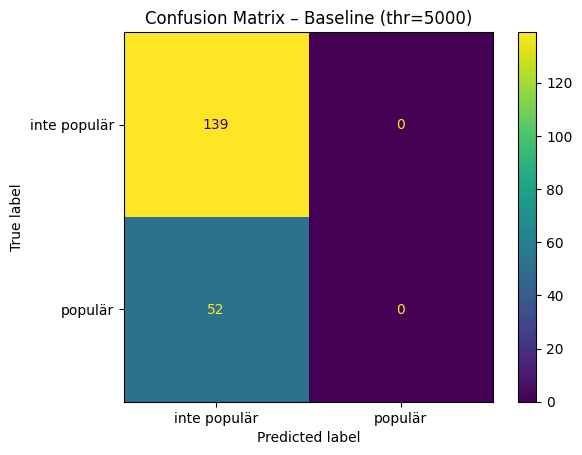


Oversampled @ 5000  accuracy: 0.565
              precision    recall  f1-score   support

inte populär       0.79      0.55      0.65       139
     populär       0.33      0.60      0.43        52

    accuracy                           0.57       191
   macro avg       0.56      0.58      0.54       191
weighted avg       0.66      0.57      0.59       191



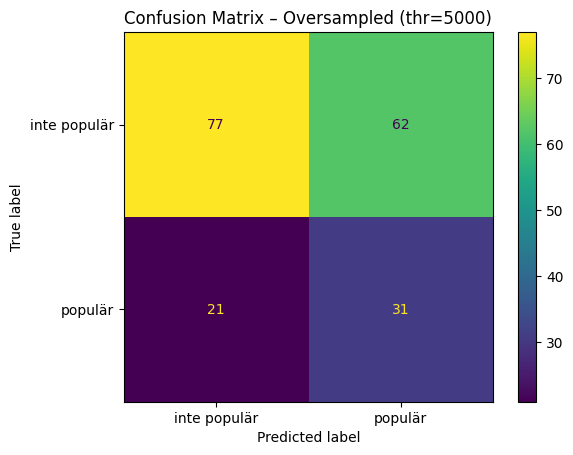

In [75]:
# Build labels at chosen threshold
y_final = label_by_threshold(best_thr)

# Baseline
acc_b, f1_b, (yte_b, yhat_b), clf_b, (Xtr_b, Xte_b, ytr_b, yte_b_) = run_once(X, y_final, oversample=False)
print(f"Baseline @ {best_thr}  accuracy: {acc_b:.3f}")
print(classification_report(yte_b, yhat_b, zero_division=0))

# Confusion matrix baseline
ConfusionMatrixDisplay.from_predictions(yte_b, yhat_b, labels=["inte populär","populär"])
plt.title(f"Confusion Matrix – Baseline (thr={best_thr})")
plt.show()

# Oversampled
acc_o, f1_o, (yte_o, yhat_o), clf_o, (Xtr_o, Xte_o, ytr_o, yte_o_) = run_once(X, y_final, oversample=True)
print(f"\nOversampled @ {best_thr}  accuracy: {acc_o:.3f}")
print(classification_report(yte_o, yhat_o, zero_division=0))

# Confusion matrix oversampled
ConfusionMatrixDisplay.from_predictions(yte_o, yhat_o, labels=["inte populär","populär"])
plt.title(f"Confusion Matrix – Oversampled (thr={best_thr})")
plt.show()

Block H — Short Markdown (paste as a Markdown cell)

### Why these steps
- We analysed which features correlate with playlists/streams to justify inputs.
- We reported **train-set** class balance at the current 5000 threshold, as requested.
- We swept thresholds (2000–10000) to study how balance and macro-F1 change.
- We selected the threshold that maximises **macro-F1 with oversampling** to improve fairness.
- We showed **classification reports** and **confusion matrices** for baseline vs oversampled.
- If accuracy stays limited, we can argue the signal in features is weak for this target, which is an acceptable conclusion when justified by the analysis.